# Sentiment Analysis Using Tensorflow (NLP Transfer Learning)

Working versions:
- TensorFlow 2.15.0
- TensorFlow Datasets 4.9.2
- NumPy 1.26.x
- Protobuf 4.23.4

### Setup and imports

In [5]:
import os
import numpy as np
import tensorflow as tf
import os, random, re, json
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pickle

# For reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Parameters and paths 

In [6]:
GLOVE_PATH = "glove.6B.100d.txt"   # Make sure this file is in the same directory as this notebook
EMBED_DIM = 100
MAX_WORDS = 20000
MAX_LEN = 120
BATCH_SIZE = 64
EPOCHS = 10

print("Parameters initialized.")

Parameters initialized.


### Load Dataset

In [23]:
df = pd.read_csv('sentimentdataset.csv')
df = df[['Text', 'Sentiment']]
df.head(5)

,Text,Sentiment
0,Enjoying a beautiful day at the park! ...,Positive
1,Traffic was terrible this morning. ...,Negative
2,Just finished an amazing workout! 💪 ...,Positive
3,Excited about the upcoming weekend getaway! ...,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral


In [27]:
# Number of samples per sentiment class
class_counts = df['Sentiment'].value_counts()

print(class_counts)

Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Contentment        14
                   ..
Adrenaline          1
Harmony             1
ArtisticBurst       1
Radiance            1
Elegance            1
Name: count, Length: 279, dtype: int64


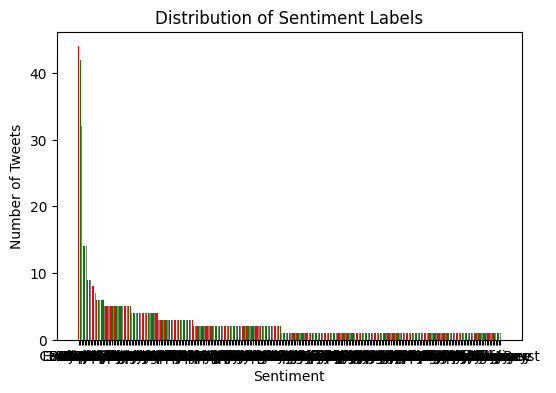

In [ ]:
import matplotlib.pyplot as plt

label_counts = df['Sentiment']['Positive'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values, color=['red', 'green', 'gray'])
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

In [ ]:
# Data Splitting
texts = df['Text'].values
# For binary classification: Map 'Positive' to 1, others to 0
labels = (df['Sentiment'] == 'Positive').astype(int).values

train_texts, test_texts, train_labels, test_labels = train_test_split(texts, labels, test_size=0.2, random_state=SEED)
train_texts, val_texts, train_labels, val_labels = train_test_split(train_texts, train_labels, test_size=0.2, random_state=SEED)

print(f'Train size: {len(train_texts)}')
print(f'Val size: {len(val_texts)}')
print(f'Test size: {len(test_texts)}')


### Tokenization and Padding

In [23]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

def texts_to_padded(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = texts_to_padded(train_texts)
X_val = texts_to_padded(val_texts)
X_test = texts_to_padded(test_texts)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

print(f"Tokenization complete. Example sequence length: {X_train.shape}")

Tokenization complete. Example sequence length: (22000, 120)


### GloVe Embeddings

In [1]:
import zipfile, os, requests

url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"

if not os.path.exists("glove.6B.100d.txt"):
    print("Downloading GloVe embeddings (862MB)... please wait 1–3 minutes.")
    r = requests.get(url, stream=True)
    with open(glove_zip, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)
    print("Extracting GloVe files...")
    with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Done!")
else:
    print("GloVe file already exists.")

KeyboardInterrupt: 

In [26]:
def load_glove_embeddings(glove_path, word_index, embed_dim=100, max_words=20000):
    embeddings_index = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            word = parts[0]
            coefs = np.asarray(parts[1:], dtype='float32')
            embeddings_index[word] = coefs

    print(f"Loaded {len(embeddings_index):,} GloVe word vectors.")

    num_words = min(max_words, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embed_dim))
    for word, i in word_index.items():
        if i < num_words:
            vec = embeddings_index.get(word)
            if vec is not None:
                embedding_matrix[i] = vec
    return embedding_matrix

embedding_matrix = load_glove_embeddings(GLOVE_PATH, tokenizer.word_index, EMBED_DIM, MAX_WORDS)

Loaded 400,000 GloVe word vectors.


### Build Model

In [27]:
from tensorflow.keras import layers, models, optimizers, callbacks

def build_model(num_words, embed_dim, max_len, embedding_matrix=None):
    inp = layers.Input(shape=(max_len,))
    if embedding_matrix is not None:
        emb = layers.Embedding(
            input_dim=num_words,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            trainable=False,  # freeze GloVe weights initially
            input_length=max_len
        )(inp)
    else:
        emb = layers.Embedding(num_words, embed_dim, input_length=max_len)(inp)
    
    x = layers.Bidirectional(layers.LSTM(64))(emb)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

num_words = min(MAX_WORDS, len(tokenizer.word_index) + 1)
model = build_model(num_words, EMBED_DIM, MAX_LEN, embedding_matrix)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 120)]             0         
                                                                 
 embedding (Embedding)       (None, 120, 100)          2000000   
                                                                 
 bidirectional (Bidirection  (None, 128)               84480     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                             

### Train Model

In [28]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=2
)

print("Training complete.")

Epoch 1/10



344/344 - 38s - loss: 0.6109 - accuracy: 0.6600 - val_loss: 0.5062 - val_accuracy: 0.7533 - 38s/epoch - 111ms/step
Epoch 2/10
344/344 - 45s - loss: 0.5111 - accuracy: 0.7598 - val_loss: 0.4601 - val_accuracy: 0.7867 - 45s/epoch - 132ms/step
Epoch 3/10
344/344 - 51s - loss: 0.4583 - accuracy: 0.7890 - val_loss: 0.4271 - val_accuracy: 0.7993 - 51s/epoch - 149ms/step
Epoch 4/10
344/344 - 30s - loss: 0.4251 - accuracy: 0.8057 - val_loss: 0.4022 - val_accuracy: 0.8150 - 30s/epoch - 88ms/step
Epoch 5/10
344/344 - 92s - loss: 0.4047 - accuracy: 0.8185 - val_loss: 0.3925 - val_accuracy: 0.8213 - 92s/epoch - 268ms/step
Epoch 6/10
344/344 - 134s - loss: 0.3869 - accuracy: 0.8264 - val_loss: 0.3888 - val_accuracy: 0.8283 - 134s/epoch - 390ms/step
Epoch 7/10
344/344 - 42s - loss: 0.3693 - accuracy: 0.8405 - val_loss: 0.3955 - val_accuracy: 0.8250 - 42s/epoch - 121ms/step
Epoch 8/10
344/344 - 41s - loss: 0.3519 - accuracy: 0.8491 - val_loss: 0.3761 - val_accuracy: 0.8267 - 41s/epoch - 120ms/step
Ep

### Evaluate Model and Check Calibration

98/98 [==============================] - 9s 81ms/step
Before calibration: Brier = 0.1409, AUC = 0.9082


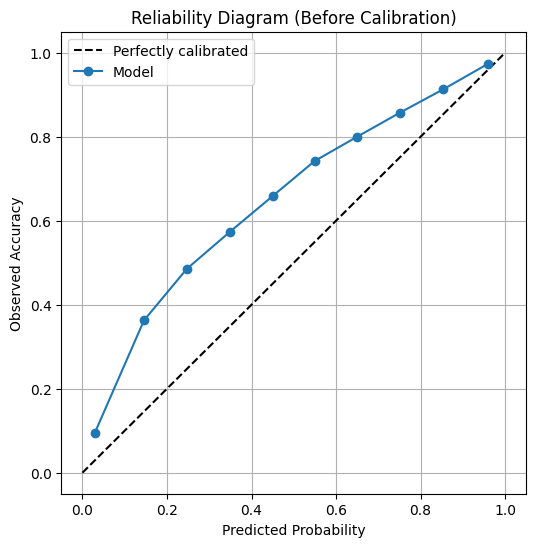

In [29]:
y_prob_test = model.predict(X_test, batch_size=256).ravel()
brier_raw = brier_score_loss(y_test, y_prob_test)
auc_raw = roc_auc_score(y_test, y_prob_test)
print(f"Before calibration: Brier = {brier_raw:.4f}, AUC = {auc_raw:.4f}")

# Reliability diagram
def reliability_diagram(y_true, y_prob, bins=10):
    bin_edges = np.linspace(0.0, 1.0, bins + 1)
    bin_indices = np.digitize(y_prob, bin_edges) - 1
    accuracies, confidences = [], []
    for i in range(bins):
        idx = bin_indices == i
        if np.any(idx):
            accuracies.append(np.mean(y_true[idx]))
            confidences.append(np.mean(y_prob[idx]))
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    plt.plot(confidences, accuracies, 'o-', label='Model')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Accuracy')
    plt.title('Reliability Diagram (Before Calibration)')
    plt.legend()
    plt.grid(True)
    plt.show()

reliability_diagram(y_test, y_prob_test)

### Temperature Scaling

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def nll_fn(T, logits, y):
    p = 1 / (1 + np.exp(-logits / T))
    return log_loss(y, p)

p_val = model.predict(X_val, batch_size=256).ravel()
logits_val = np.log(p_val / (1 - p_val + 1e-8))

p_test = model.predict(X_test, batch_size=256).ravel()
logits_test = np.log(p_test / (1 - p_test + 1e-8))

res = minimize(nll_fn, 1.0, args=(logits_val, y_val), method='L-BFGS-B', bounds=[(0.01, 50)])
T_opt = res.x[0]
print(f'Optimal Temperature: {T_opt:.4f}')

probs_test_cal = 1 / (1 + np.exp(-logits_test / T_opt))


Shapes:
  p_val: (3000,)
  logits_val: (3000,)
  y_val: (3000,)
  p_test: (25000,)
  logits_test: (25000,)
  y_test: (25000,)

Prob ranges:
  p_val min/max: 0.00036903142 0.9990343
  p_test min/max: 0.00036705853 0.99932086

Temperature: 1.0

Metrics on TEST set:
  Raw Brier:       0.1409
  Calibrated Brier:0.1409
  Raw AUC:         0.9082
  Calibrated AUC:  0.9082


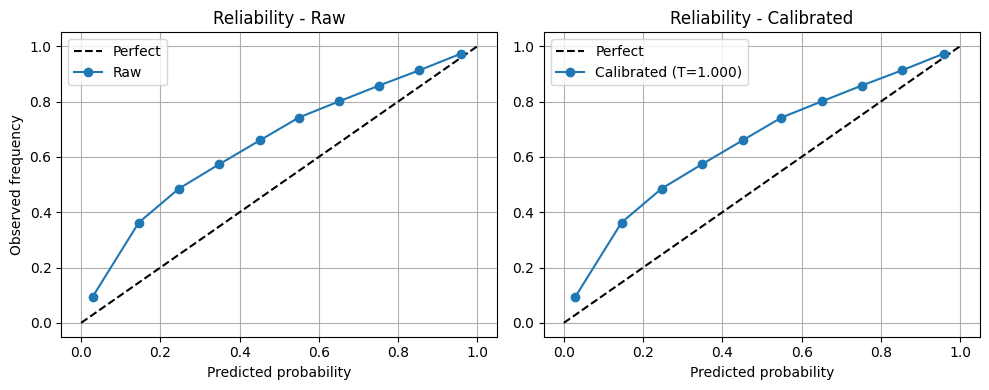

In [33]:
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt

#  Basic sanity checks (should pass) 
print("Shapes:")
print("  p_val:", p_val.shape)
print("  logits_val:", logits_val.shape)
print("  y_val:", y_val.shape)
print("  p_test:", p_test.shape)
print("  logits_test:", logits_test.shape)
print("  y_test:", y_test.shape)

# Should be equal-length vectors
assert logits_val.shape[0] == y_val.shape[0], "val size mismatch"
assert logits_test.shape[0] == y_test.shape[0], "test size mismatch"

# Probabilities should be in (0,1)
print("\nProb ranges:")
print("  p_val min/max:", p_val.min(), p_val.max())
print("  p_test min/max:", p_test.min(), p_test.max())

# Temperature should be positive and reasonable
print("\nTemperature:", T_opt)
if not (0.01 < T_opt < 50):
    print("Temperature is unusual — may indicate problems (very small or very large).")

# Numeric metrics (raw vs calibrated)
p_test_raw = p_test
p_test_cal = probs_test_cal  # from previous cell
print("\nMetrics on TEST set:")
print(f"  Raw Brier:       {brier_score_loss(y_test, p_test_raw):.4f}")
print(f"  Calibrated Brier:{brier_score_loss(y_test, p_test_cal):.4f}")
print(f"  Raw AUC:         {roc_auc_score(y_test, p_test_raw):.4f}")
print(f"  Calibrated AUC:  {roc_auc_score(y_test, p_test_cal):.4f}")

# Quick reliability diagrams (visual check) 
def reliability_points(y, probs, bins=10):
    bins_edges = np.linspace(0,1,bins+1)
    bin_idx = np.digitize(probs, bins_edges) - 1
    confs, accs, counts = [], [], []
    for i in range(bins):
        idx = bin_idx == i
        if np.any(idx):
            confs.append(probs[idx].mean())
            accs.append(y[idx].mean())
            counts.append(idx.sum())
        else:
            confs.append(np.nan); accs.append(np.nan); counts.append(0)
    return np.array(confs), np.array(accs), np.array(counts)

confs_raw, accs_raw, counts_raw = reliability_points(y_test, p_test_raw)
confs_cal, accs_cal, counts_cal = reliability_points(y_test, p_test_cal)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot([0,1],[0,1],'k--', label='Perfect')
plt.plot(confs_raw, accs_raw, 'o-', label='Raw')
plt.title('Reliability - Raw')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot([0,1],[0,1],'k--', label='Perfect')
plt.plot(confs_cal, accs_cal, 'o-', label=f'Calibrated (T={T_opt:.3f})')
plt.title('Reliability - Calibrated')
plt.xlabel('Predicted probability')
plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()

### Apply Temperature Scaling

After calibration: Brier = 0.1409, AUC = 0.9082


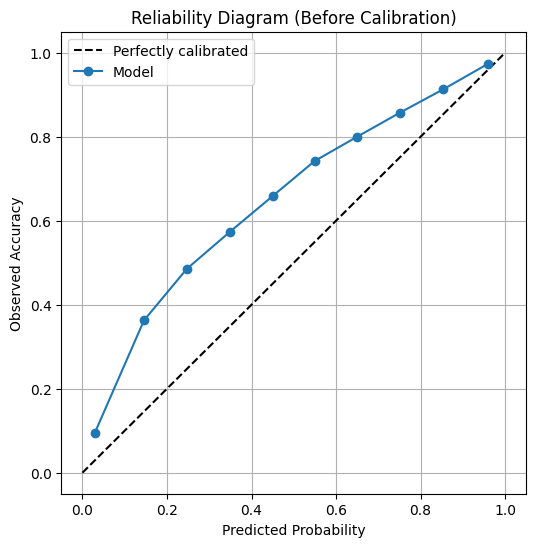

In [34]:
scaled_probs = 1 / (1 + np.exp(-logits_test / T_opt))
brier_scaled = brier_score_loss(y_test, scaled_probs)
auc_scaled = roc_auc_score(y_test, scaled_probs)

print(f"After calibration: Brier = {brier_scaled:.4f}, AUC = {auc_scaled:.4f}")

# Plot new reliability
reliability_diagram(y_test, scaled_probs)

### Save Model and Tokenizer

In [35]:
SAVE_DIR = "sentiment_model_glove"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save(SAVE_DIR, include_optimizer=False)

with open(os.path.join(SAVE_DIR, "tokenizer_meta.pkl"), "wb") as f:
    pickle.dump({
        "tokenizer": tokenizer,
        "max_len": MAX_LEN,
        "temperature": T_opt
    }, f)

print("Model and tokenizer saved successfully.")

INFO:tensorflow:Assets written to: sentiment_model_glove\assets


INFO:tensorflow:Assets written to: sentiment_model_glove\assets


Model and tokenizer saved successfully.


### Quick Test

In [36]:
sample_texts = [
    "I absolutely loved this movie!",
    "The plot was boring and predictable.",
    "This product exceeded my expectations."
]

for text in sample_texts:
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    raw_prob = model.predict(padded)[0,0]
    logit = np.log(raw_prob / (1 - raw_prob + 1e-8))
    scaled_prob = 1 / (1 + np.exp(-logit / T_opt))
    sentiment = "Positive" if scaled_prob >= 0.5 else "Negative"
    print(f"Text: {text}\n→ {sentiment} ({scaled_prob*100:.1f}%)\n")

1/1 [==============================] - 0s 312ms/step
Text: I absolutely loved this movie!
→ Positive (93.8%)

1/1 [==============================] - 0s 28ms/step
Text: The plot was boring and predictable.
→ Negative (2.1%)

1/1 [==============================] - 0s 42ms/step
Text: This product exceeded my expectations.
→ Negative (26.6%)

